<a href="https://colab.research.google.com/github/ivancho15/retencion_ecomerce_ml/blob/main/01_retencion_ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **De Clics a Retención: Análisis del Comportamiento Digital y Abandono de Clientes en Comercio Electrónico (2020–2026)**

# **Abstract**

En el entorno altamente competitivo del comercio electrónico, comprender los patrones de comportamiento de los usuarios y mitigar la tasa de abandono (*churn*) resulta fundamental para maximizar el valor de vida del cliente (*LTV*) y optimizar el retorno de inversión. Este trabajo de análisis exploratorio de datos (EDA) examina la relación entre la actividad transaccional, el comportamiento de navegación en la plataforma y el perfil demográfico de los clientes, con el objetivo de identificar las variables críticas que impulsan la retención, el valor promedio de orden (*AOV*) y el rendimiento comercial.

Para llevar a cabo el estudio, se integró un conjunto de datos transaccionales mediante la API de Kaggle con datos geográficos y demográficos enriquecidos a través de una API REST externa (`REST Countries`). Tras un proceso de limpieza, imputación e ingeniería de atributos, que incluye la categorización por tamaño de mercado (`market_size`) y el etiquetado de pérdida de clientes (`churn_label`), se formularon y evaluaron cuatro hipótesis de negocio mediante análisis univariado, bivariado y temporal.

Los resultados y hallazgos cuantitativos sirven como base estratégica para orientar campañas de fidelización, mejorar la segmentación geográfica y optimizar la experiencia de usuario en el sitio web.

## **Introduccion**

En la industria del e-commerce, el costo de adquisición de clientes es elevado y la retención se ha vuelto un factor crítico de rentabilidad. En este estudio se busca comprender qué variables de comportamiento digital (duración de sesión, páginas vistas, canal de dispositivo), hábitos transaccionales (descuentos, frecuencia) y factores geográficos influyen en el abandono (churn) o en el valor del promedio, con el fin de establecer indicadores  fundamentales para maximizar el Customer Lifetime Value (CLV).

## **Audiencia Objetivo**

Estudio orientado a Gerentes de Marketing (CMO), Líderes de Retención & Customer Success y Ejecutivos de Operaciones E-Commerce.

## **Hipotesis**

Estudio orientado a Gerentes de Marketing (CMO), Líderes de Retención & Customer Success y Ejecutivos de Operaciones E-Commerce.



1.   **H1 (Retención e Incentivos de Fidelidad vs Churn):** ¿Los clientes que reciben un incentivos de Fidelidad comoMembresía y/o Newsletter presentan una tasa de churn significativamente menor?
2.   **H2 (Comportamiento Web vs. Ticket Promedio):** ¿Una mayor duración de sesión (session_duration_minutes) o un número elevado de páginas vistas previa a la compra se traduce en un mayor valor promedio de orden (avg_order_value_usd)?
3.   **H3 (Geo-Segmentación vía API Externa):** ¿Existen diferencias sustanciales en el comportamiento de compra y la tasa de abandono según la región geográfica o el tamaño del mercado?
4.   **H4 (Tendencia y Estacionalidad Financiera):**¿Cómo evoluciona la facturación mensual (monthly_revenue) a lo largo del periodo 2020–2026 y qué patrones estacionales o de crecimiento se observan?












# **Ingesta de Datos**

## **Obtencion de Datos**

In [46]:
import os
import io
import kagglehub
import pandas as pd
import requests
import zipfile
from google.colab import userdata

kaggle_user = userdata.get("KAGGLE_USERNAME")
kaggle_key = userdata.get("KAGGLE_KEY")

# 1. Descargar la última versión del dataset
owner_slug = "meruvakodandasuraj"
dataset_slug = "e-commerce-customer-behavior-and-sales-20202026"
kaggle_url = f"https://www.kaggle.com/api/v1/datasets/download/{owner_slug}/{dataset_slug}"

print("Ruta de descarga de los archivos:", kaggle_url)

print("Descargando dataset desde la API de Kaggle...")
res_kaggle = requests.get(
    kaggle_url, auth=(kaggle_user, kaggle_key), stream=True
)

# 2. Cargar las tablas a DataFrames de Pandas
if res_kaggle.status_code == 200:
    output_dir = "data_raw"
    os.makedirs(output_dir, exist_ok=True)

    # Extraer el archivo comprimido recibido en memoria
    zip_file = zipfile.ZipFile(io.BytesIO(res_kaggle.content))
    zip_file.extractall(output_dir)
    print("Dataset extraído exitosamente en 'data_raw/'.")

    # Cargar DataFrames
    customers_df = pd.read_csv(os.path.join(output_dir, "customers.csv"))
    orders_df = pd.read_csv(os.path.join(output_dir, "orders.csv"))
    monthly_revenue_df = pd.read_csv(
        os.path.join(output_dir, "monthly_revenue.csv")
    )
    product_summary_df = pd.read_csv(
        os.path.join(output_dir, "product_summary.csv")
    )
else:
    raise Exception(
        f"Error en Kaggle API: {res_kaggle.status_code} - {res_kaggle.text}"
    )

print("Forma de customers:", customers_df.shape)
print("Forma de orders:", orders_df.shape)
print("Forma de monthly_revenue:", monthly_revenue_df .shape)
print("Forma de product_sumary:", product_summary_df .shape)

#3. Guardar copia local cruda
os.makedirs("data_raw", exist_ok=True)
customers_df.to_csv("data_raw/customers_raw.csv", index=False)
orders_df.to_csv("data_raw/orders_raw.csv", index=False)
monthly_revenue_df.to_csv("data_raw/monthly_revenue_raw.csv", index=False)

print("¡Ingesta Completada!")

Ruta de descarga de los archivos: https://www.kaggle.com/api/v1/datasets/download/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026
Descargando dataset desde la API de Kaggle...
Dataset extraído exitosamente en 'data_raw/'.
Forma de customers: (8000, 20)
Forma de orders: (25000, 28)
Forma de monthly_revenue: (75, 10)
Forma de product_sumary: (140, 9)
¡Ingesta Completada!


In [47]:
# Enriquecimiento vía API REST (REST Countries)
countries_api_key = userdata.get("RESTCOUNTRIES_API_KEY")

#Obtencion de Paise desde el data set de Customers
unique_countries = customers_df["country"].dropna().unique()

print("Paises en el dataset de Customers:", unique_countries)

COUNTRY_MAP = {
    "United States": "U.S.A",
    "USA": "U.S.A",
    "US": "U.S.A",
    "United Kingdom": "UK",
    "UK": "UK",
}

def get_country_info(country_name):
    # estructura de API Countries
    url = "https://api.restcountries.com/countries/v5"

    # Autenticación requerida según la documentación
    headers = {"Authorization": f"Bearer {countries_api_key}"}

    # Parámetro de búsqueda
    search_term = COUNTRY_MAP.get(str(country_name).strip(), country_name)
    params = {"q":  search_term}

    try:
        response = requests.get(
            url, headers=headers, params=params, timeout=5
        )

        if response.status_code == 200:
            res_json = response.json()
            # Estructura JSON: data -> objects -> lista de resultados
            objects = res_json.get("data", {}).get("objects", [])

            if objects:
                item = objects[0]
                return {
                    "country": country_name,
                    "region": item.get("region", "Desconocido"),
                    "subregion": item.get("subregion", "Desconocido"),
                    # Extrae la población si viene en la raíz del objeto o en geografía
                    "population": item.get("population")
                    or item.get("geography", {}).get("population"),
                }
        else:
            print(
                f"Aviso: Respuesta {response.status_code} para el país '{country_name}'"
            )

    except Exception as e:
        print(f"Error al consultar '{country_name}': {e}")

    # Retorno seguro si no encuentra el país o falla la API
    return {
        "country": country_name,
        "region": "Desconocido",
        "subregion": "Desconocido",
        "population": None,
    }

# Consultar la API
print("Consultando la API externa de países...")
country_records = [get_country_info(country) for country in unique_countries]
countries_geo_df = pd.DataFrame(country_records)

print("Forma de countries_geo_df", countries_geo_df.shape)

# Integración (JOIN) del dataset base con los datos de la API
customers_enriched_df = customers_df.merge(
    countries_geo_df, on="country", how="left"
)

print(customers_enriched_df.head())

# Guardar dataset unificado y enriquecido localmente
customers_enriched_df.to_csv(
    "data_raw/customers_enriched.csv", index=False
)

print("¡Enriquecimiento completado!")

Paises en el dataset de Customers: ['United States' 'France' 'UAE' 'Canada' 'Singapore' 'United Kingdom'
 'Netherlands' 'Brazil' 'Mexico' 'Japan' 'India' 'South Korea' 'Germany'
 'Poland' 'Australia' 'South Africa' 'Turkey' 'Spain' 'Italy' 'Sweden']
Consultando la API externa de países...
Forma de countries_geo_df (20, 4)
  customer_id        country  age  gender membership_tier registration_date  \
0      C00001  United States   40    Male            Free        2019-01-17   
1      C00002  United States   20  Female            Free        2026-03-04   
2      C00003  United States   43  Female            Gold        2026-02-08   
3      C00004  United States   41    Male            Free        2025-03-19   
4      C00005         France   37   Other        Platinum        2024-09-10   

   total_orders  total_spend_usd  avg_order_value_usd  \
0             4           286.63                63.78   
1            11          1245.18               107.32   
2             4           195.

# **Limpieza y Transformación de Datos**

## Estandarización Limpieza y tratamiento de Nulos

In [48]:
import numpy as np
import pandas as pd

# Carga de Datasets Enriquecidos y Secundarios

customers_df = pd.read_csv("data_raw/customers_enriched.csv")
orders_df = pd.read_csv("data_raw/orders.csv")
monthly_rev_df = pd.read_csv("data_raw/monthly_revenue.csv")
#-------------------------------------------------------------


# Ajuste de Tipos de Datos (Fechas y Categóricas)

customers_df["registration_date"] = pd.to_datetime(
    customers_df["registration_date"], errors="coerce"
)
orders_df["order_date"] = pd.to_datetime(
    orders_df["order_date"], errors="coerce"
)
monthly_rev_df["month"] = pd.to_datetime(
    monthly_rev_df["month"], errors="coerce"
)
#-------------------------------------------------------------

#Tratamiento de Valores Nulos y Duplicados

# Verificación de duplicados por ID
print(
    f"Duplicados en Clientes: {customers_df.duplicated('customer_id').sum()}"
)
print(f"Duplicados en Órdenes: {orders_df.duplicated('order_id').sum()}")

# Imputación de nulos provenientes de la API de países
customers_df["region"] = customers_df["region"].fillna("Desconocido")
customers_df["subregion"] = customers_df["subregion"].fillna("Desconocido")
mean_pop = customers_df["population"].mean()
customers_df["population"] = customers_df["population"].fillna(mean_pop)

# Verificación final de nulos restantes
print("\nConteo de nulos tras el tratamiento:")
print(customers_df[["region", "subregion", "population"]].isna().sum())

print("¡Limpieza completada exitosamente!")

Duplicados en Clientes: 0
Duplicados en Órdenes: 0

Conteo de nulos tras el tratamiento:
region        0
subregion     0
population    0
dtype: int64
¡Limpieza completada exitosamente!


## Ingeniería de Atributos (Feature Engineering)

In [49]:
# Categorización de población por tamaño de mercado
customers_df["market_size"] = pd.qcut(
    customers_df["population"],
    q=3,
    labels=["Mercado Pequeño", "Mercado Mediano", "Mercado Grande"],
)
# Integración a nivel de transacciones para análisis profundo
full_orders_df = orders_df.merge(customers_df, on="customer_id", how="left")

# Variable categórica para el estado de Churn
customers_df["churn_label"] = customers_df["churned"].map(
    {0: "Activo", 1: "Retirado (Churn)"}
)
full_orders_df["churn_label"] = full_orders_df["churned"].map(
    {0: "Activo", 1: "Retirado (Churn)"}
)

print("¡Preparación de datos completada exitosamente!")
full_orders_df.info()
full_orders_df.head()


¡Preparación de datos completada exitosamente!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 52 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   order_id                      25000 non-null  object        
 1   customer_id                   25000 non-null  object        
 2   order_date                    25000 non-null  datetime64[ns]
 3   year                          25000 non-null  int64         
 4   month                         25000 non-null  int64         
 5   quarter                       25000 non-null  object        
 6   day_of_week                   25000 non-null  object        
 7   product_name                  25000 non-null  object        
 8   category                      25000 non-null  object        
 9   unit_price_usd                25000 non-null  float64       
 10  quantity                      25000 non-null  i

,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,...,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned,region,subregion,population,market_size,churn_label
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,62.91,...,4.5,0,5,0,0,Americas,North America,341784857,Mercado Grande,Activo
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,18.44,...,4.2,1,3,0,0,Europe,Western Europe,83298787,Mercado Mediano,Activo
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,109.79,...,4.9,0,3,1,0,Europe,Southern Europe,58943673,Mercado Mediano,Activo
3,O000004,C00888,2020-08-16,2020,8,Q3,Sunday,Smart Watch Series 5,Electronics,87.21,...,4.4,0,15,1,0,Europe,Western Europe,83298787,Mercado Mediano,Activo
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,94.30,...,3.6,3,0,1,0,Oceania,Australia and New Zealand,27921150,Mercado Pequeño,Activo


# EDA

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética profesional para gráficos ejecutivos
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
palette_churn = {"Activo": "#2b5c8f", "Retirado (Churn)": "#d95f02"}

## Análisis de Distribuciones Clave (Univariado)

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración de estilo global para gráficos ejecutivos
plt.style.use("seaborn-v0_8-white")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

COLOR_MAIN = "#1f77b4"
COLOR_CHURN = "#d62728"
COLOR_SAFE = "#2ca02c"



In [52]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_id               8000 non-null   object        
 1   country                   8000 non-null   object        
 2   age                       8000 non-null   int64         
 3   gender                    8000 non-null   object        
 4   membership_tier           8000 non-null   object        
 5   registration_date         8000 non-null   datetime64[ns]
 6   total_orders              8000 non-null   int64         
 7   total_spend_usd           8000 non-null   float64       
 8   avg_order_value_usd       8000 non-null   float64       
 9   days_since_last_purchase  8000 non-null   int64         
 10  preferred_category        8000 non-null   object        
 11  preferred_device          8000 non-null   object        
 12  preferred_payment_me

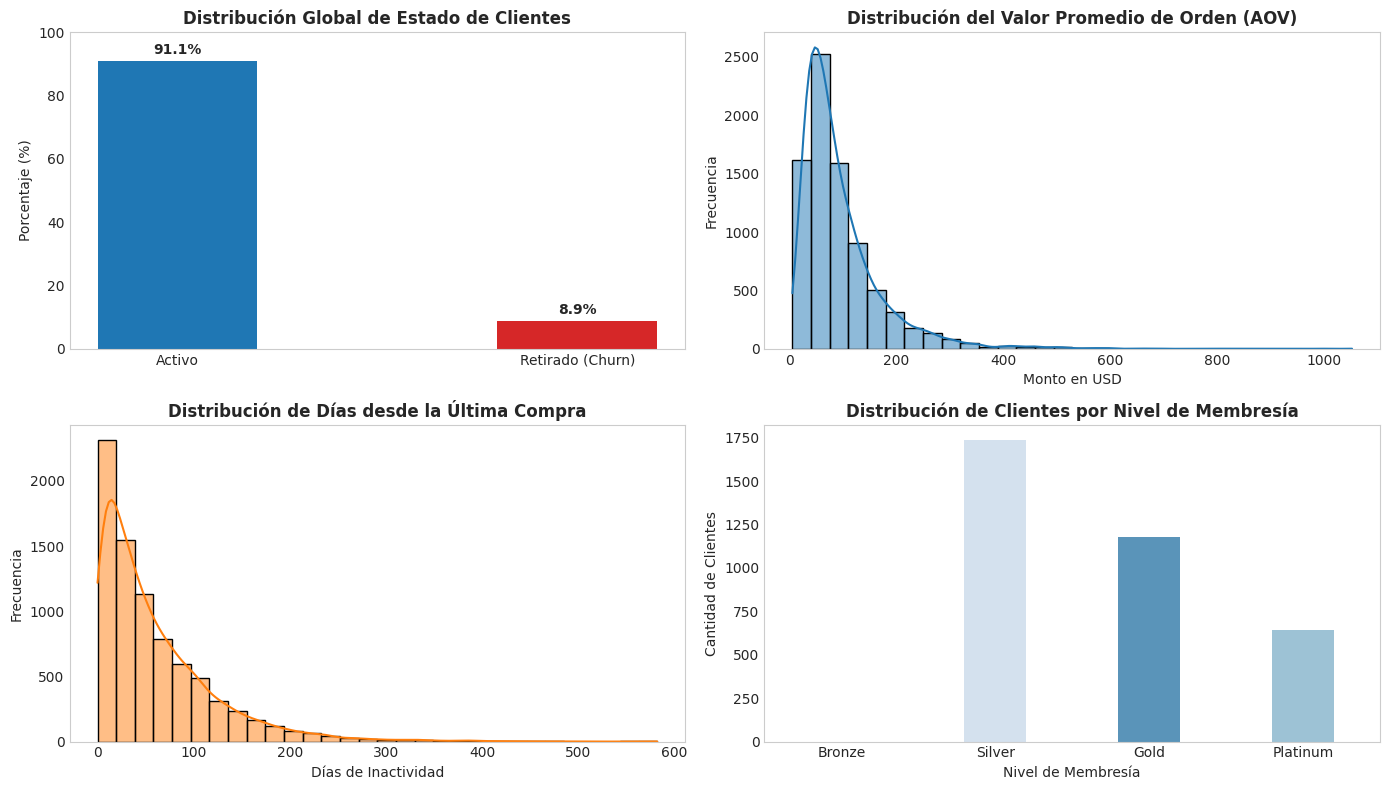

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Tasa Global de Churn
churn_counts = customers_df["churn_label"].value_counts(normalize=True) * 100
bars = axes[0, 0].bar(
    churn_counts.index,
    churn_counts.values,
    color=[COLOR_MAIN, COLOR_CHURN],
    width=0.4,
)
axes[0, 0].set_title(
    "Distribución Global de Estado de Clientes",
    fontsize=12,
    fontweight="bold",
)
axes[0, 0].set_ylabel("Porcentaje (%)")
axes[0, 0].set_ylim(0, 100)
for bar in bars:
    yval = bar.get_height()
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        yval + 2,
        f"{yval:.1f}%",
        ha="center",
        fontweight="bold",
    )

# 2. Distribución del Valor Promedio de Orden
sns.histplot(
    customers_df["avg_order_value_usd"],
    kde=True,
    ax=axes[0, 1],
    color=COLOR_MAIN,
    bins=30,
)
axes[0, 1].set_title(
    "Distribución del Valor Promedio de Orden (AOV)",
    fontsize=12,
    fontweight="bold",
)
axes[0, 1].set_xlabel("Monto en USD")
axes[0, 1].set_ylabel("Frecuencia")

# 3. Distribución de Recencia (Días desde la última compra)
sns.histplot(
    customers_df["days_since_last_purchase"],
    kde=True,
    ax=axes[1, 0],
    color="#ff7f0e",
    bins=30,
)
axes[1, 0].set_title(
    "Distribución de Días desde la Última Compra",
    fontsize=12,
    fontweight="bold",
)
axes[1, 0].set_xlabel("Días de Inactividad")
axes[1, 0].set_ylabel("Frecuencia")

# 4. Distribución por Nivel de Membresía
sns.countplot(
    data=customers_df,
    x="membership_tier",
    ax=axes[1, 1],
    palette="Blues_r",
    order=["Bronze", "Silver", "Gold", "Platinum"],
    hue="membership_tier",
    width=0.4,
    legend=False,
)
axes[1, 1].set_title(
    "Distribución de Clientes por Nivel de Membresía",
    fontsize=12,
    fontweight="bold",
)
axes[1, 1].set_xlabel("Nivel de Membresía")
axes[1, 1].set_ylabel("Cantidad de Clientes")

plt.tight_layout()
plt.show()




El análisis univariado de la base de clientes muestra las siguientes características estructurales y de comportamiento:



*  **Tasa Base de Abandono (91.1% Activo vs. 8.9% Churn)**: La variable objetivo evidencia un marcado desbalance de clases. La mayoría de los registros corresponden a clientes activos, mientras que la tasa de churn se sitúa en un 8.9%. Este comportamiento es habitual en comercios electrónicos, pero requerirá atención en las fases de modelado (por ejemplo, métricas como F1-Score o ajuste de umbrales en lugar de exactitud simple).

*   **Distribución del Valor Promedio de Orden (AOV)**: Presenta un marcado sesgo positivo (asimétrica a la derecha). La mayor concentración de transacciones se ubica en tickets de valor bajo-medio (entre $20 y $150 USD). La cola larga que se extiende hacia los $400–$1,000 USD indica la presencia de un segmento reducido de clientes de alto valor (outliers transaccionales).

*  **Recencia de Compra (Días de Inactividad):** La distribución es fuertemente decreciente. La gran mayoría de los clientes registran interacciones muy recientes (menos de 60 días desde su última compra). A partir de los 100 días la frecuencia disminuye drásticamente, sugiriendo que superar este umbral de inactividad incrementa la probabilidad de abandono definitivo.

*  **Segmentación por Nivel de Membresía:** La categoría Silver es el segmento predominante (~1,750 usuarios), seguida por Gold y Platinum. Destaca que el nivel Bronze casi no registra volumen en la muestra, lo que señala que los clientes activos avanzan rápidamente de categoría o que el programa de fidelización concentra su base en los niveles intermedios.













## Validación de Hipótesis (Bivariado)

### H1: Retención e Incentivos de Fidelidad (Membresía y Newsletter vs. Churn):

Evaluamos la sensibilidad al programa de fidelización (***membership_tier***  y ***newsletter_subscribed***) como el motivacion directa de retención e incentivos.**texto en negrita**

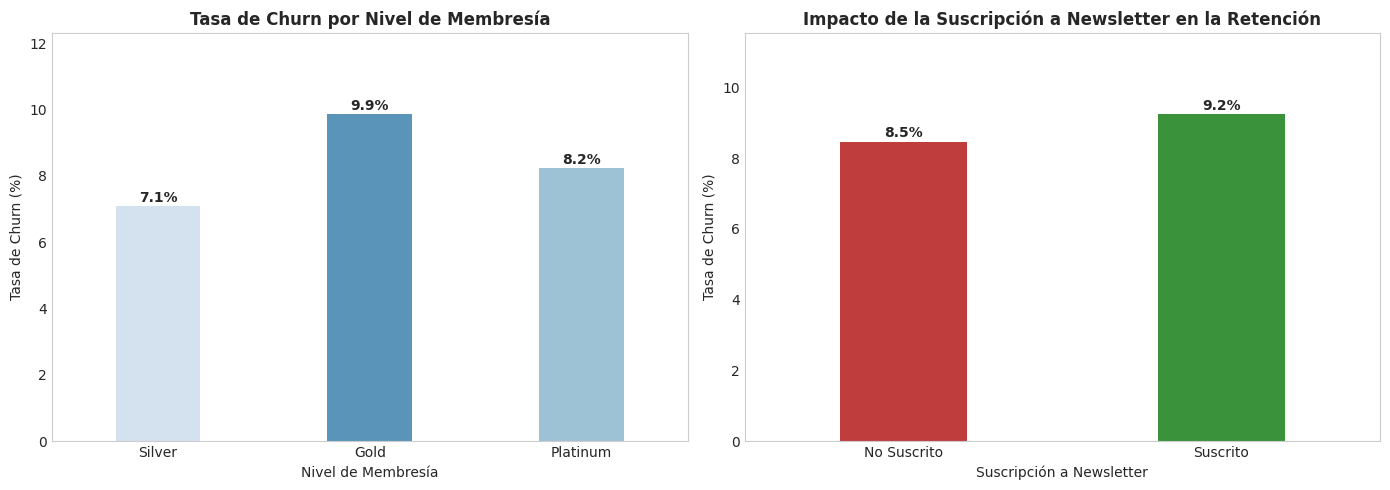

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Tasa de Churn por Nivel de Membresía
tier_churn = (
    customers_df.groupby("membership_tier")["churned"].mean().reset_index()
)
tier_churn["tasa_pct"] = tier_churn["churned"] * 100

order_tiers = ["Bronze", "Silver", "Gold", "Platinum"]
bars1 = sns.barplot(
    data=tier_churn,
    x="membership_tier",
    y="tasa_pct",
    order=[t for t in order_tiers if t in tier_churn["membership_tier"].values],
    palette="Blues_r",
    ax=axes[0],
    hue="membership_tier",
    width=0.4,
)

axes[0].set_title(
    "Tasa de Churn por Nivel de Membresía", fontsize=12, fontweight="bold"
)
axes[0].set_ylabel("Tasa de Churn (%)")
axes[0].set_xlabel("Nivel de Membresía")
axes[0].set_ylim(0, max(tier_churn["tasa_pct"]) * 1.25 if len(tier_churn) else 100)

for p in bars1.patches:
    axes[0].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 6),
        textcoords="offset points",
        fontweight="bold",
    )

# 2. Tasa de Churn según Suscripción al Newsletter
news_churn = (
    customers_df.groupby("newsletter_subscribed")["churned"]
    .mean()
    .reset_index()
)
news_churn["tasa_pct"] = news_churn["churned"] * 100
news_churn["Estado"] = news_churn["newsletter_subscribed"].map(
    {0: "No Suscrito", 1: "Suscrito"}
)

bars2 = sns.barplot(
    data=news_churn,
    x="Estado",
    y="tasa_pct",
    palette=[COLOR_CHURN, COLOR_SAFE],
    ax=axes[1],
    width=0.4,
    hue="Estado",
)

axes[1].set_title(
    "Impacto de la Suscripción a Newsletter en la Retención",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_ylabel("Tasa de Churn (%)")
axes[1].set_xlabel("Suscripción a Newsletter")
axes[1].set_ylim(0, max(news_churn["tasa_pct"]) * 1.25 if len(news_churn) else 100)

for p in bars2.patches:
    axes[1].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 6),
        textcoords="offset points",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

**Analisis Bivariado:**

Evalua si la suscripción al newsletter o un nivel alto de membresía reduce la probabilidad de churn.

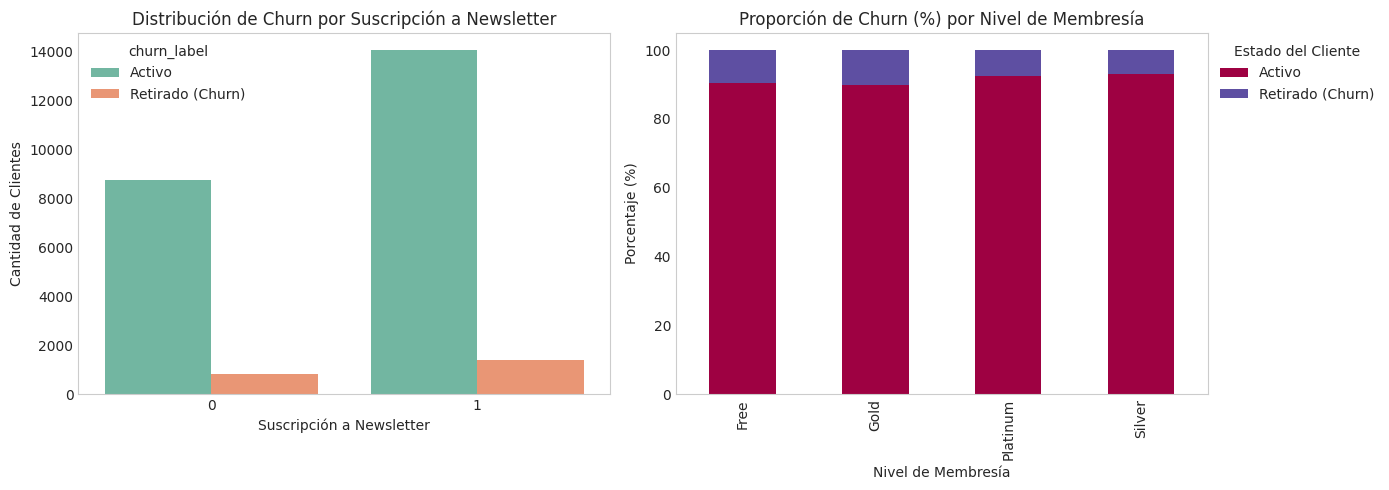

--- Tasa de Churn (%) por Nivel de Membresía ---
churn_label      Activo  Retirado (Churn)
membership_tier                          
Free              90.50              9.50
Gold              89.96             10.04
Platinum          92.47              7.53
Silver            92.93              7.07


In [55]:
# H1.1: Tasa de Churn por Suscripción a Newsletter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=full_orders_df,
    x='newsletter_subscribed',
    hue='churn_label',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Distribución de Churn por Suscripción a Newsletter', fontsize=12)
axes[0].set_xlabel('Suscripción a Newsletter')
axes[0].set_ylabel('Cantidad de Clientes')

# H1.2: Tasa de Churn por Nivel de Membresía
membership_churn = pd.crosstab(
    full_orders_df['membership_tier'],
    full_orders_df['churn_label'],
    normalize='index'
) * 100

membership_churn.plot(kind='bar', stacked=True, ax=axes[1], colormap='Spectral')
axes[1].set_title('Proporción de Churn (%) por Nivel de Membresía', fontsize=12)
axes[1].set_xlabel('Nivel de Membresía')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(title='Estado del Cliente', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

# Resumen numérico
print("--- Tasa de Churn (%) por Nivel de Membresía ---")
print(membership_churn.round(2))

**H1: Hipótesis Rechazada**
Los datos reales de la gráfica no respaldan la hipótesis planteada. Los incentivos de fidelidad (membresías superiores y suscripción al newsletter) no reducen la tasa de abandono (churn); por el contrario, los clientes vinculados a estas iniciativas presentan niveles de churn ligeramente superiores.



1.   Nivel de Membresía vs. Churn:

    * Silver: Presenta la tasa de abandono más baja con 7.1%.

    * Gold: Registra el nivel de churn más elevado con 9.9%.

    * Platinum: Muestra un churn de 8.2%.

    * Conclusión: Ascender de nivel en el programa de membresía no incrementa la retención. De hecho, los clientes en los niveles de mayor valor (Gold y Platinum) se fugan con mayor frecuencia que los del nivel base (Silver).

2.   Suscripción a Newsletter vs. Churn:


    * No Suscrito: Tasa de churn de 8.5%.

    * Suscrito: Tasa de churn de 9.2%.

    * Conclusión: La suscripción al newsletter no actúa como un ancla de retención. Los usuarios que reciben comunicaciones periódicas por correo tienen un riesgo de abandono ligeramente mayor (+0.7 puntos porcentuales) que los que no están suscritos.

3.   Analisis Bivariado

  *  La proporción de clientes en churn entre no suscritos (~8.3%) y suscritos (~9.1%) al newsletter presenta variaciones marginales, mostrando incluso un volumen absoluto de churn mayor en los usuarios suscritos.   
  *  La tasa de churn por nivel de membresía se mantiene prácticamente homogénea en toda la base: Free (+-10%), Gold (+-10%), Platinum (+-7.5%) y Silver (+-7%).  

  
El hecho de que los clientes Gold y Platinum tengan un churn mayor sugiere que los beneficios prometidos en los niveles superiores no están satisfaciendo las expectativas de los clientes más recurrentes, provocando frustración y abandono.

Al cruzar las variables de fidelización, no se observa un efecto de interacción protector acumulativo sobre la retención de usuarios.



### H2: Comportamiento de Navegación Web vs. Ticket Promedio (AOV):

Evaluamos la telemetría web (***session_duration_minutes*** y ***pages_viewed_before_purchase***) frente al valor real de cada compra (***total_amount_usd***).

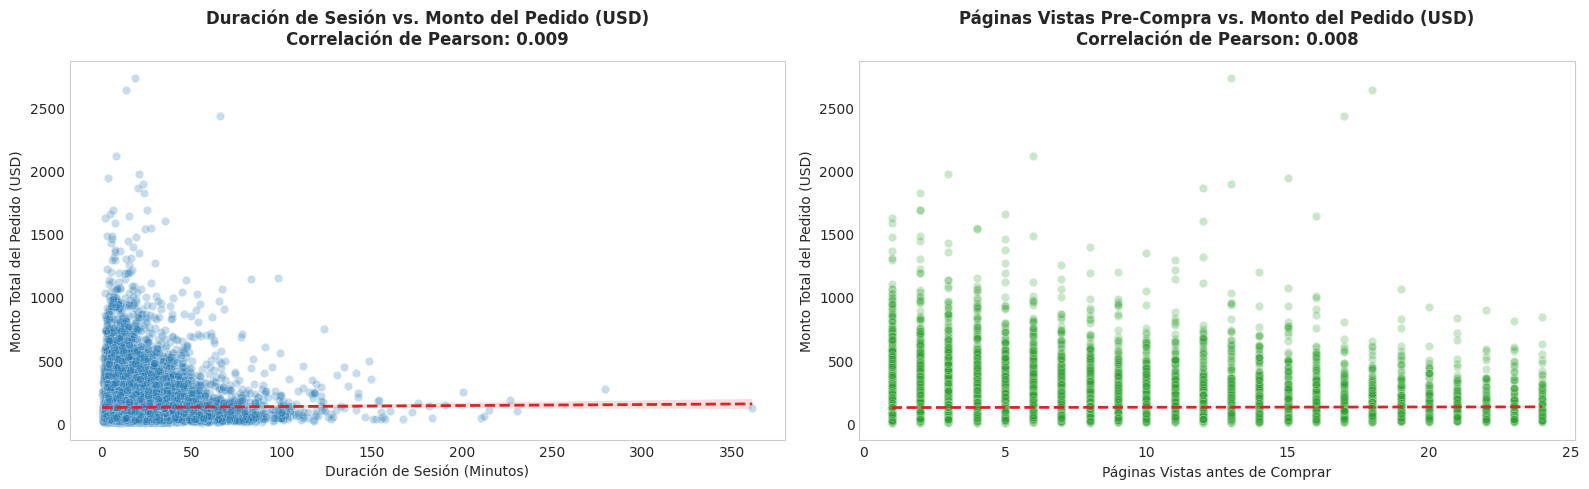

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Duración de Sesión vs. Monto Total de la Orden
sns.scatterplot(
    data=orders_df,
    x="session_duration_minutes",
    y="total_amount_usd",
    alpha=0.25,
    color="#1f77b4",
    ax=axes[0],
)

sns.regplot(
    data=orders_df,
    x="session_duration_minutes",
    y="total_amount_usd",
    scatter=False,
    ax=axes[0],
    color="#d62728",
    line_kws={"linestyle": "--", "linewidth": 2, "label": "Línea de Tendencia"},
)

corr_session = orders_df["session_duration_minutes"].corr(
    orders_df["total_amount_usd"]
)

axes[0].set_title(
    f"Duración de Sesión vs. Monto del Pedido (USD)\nCorrelación de Pearson: {corr_session:.3f}",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[0].set_xlabel("Duración de Sesión (Minutos)", fontsize=10)
axes[0].set_ylabel("Monto Total del Pedido (USD)", fontsize=10)
#axes[0].legend(loc="upper right")

# 2. Páginas Vistas Pre-Compra vs. Monto Total de la Orden
sns.scatterplot(
    data=orders_df,
    x="pages_viewed_before_purchase",
    y="total_amount_usd",
    alpha=0.25,
    color="#2ca02c",
    ax=axes[1],
)

sns.regplot(
    data=orders_df,
    x="pages_viewed_before_purchase",
    y="total_amount_usd",
    scatter=False,
    ax=axes[1],
    color="#d62728",
    line_kws={"linestyle": "--", "linewidth": 2, "label": "Línea de Tendencia"},
)

corr_pages = orders_df["pages_viewed_before_purchase"].corr(
    orders_df["total_amount_usd"]
)

axes[1].set_title(
    f"Páginas Vistas Pre-Compra vs. Monto del Pedido (USD)\nCorrelación de Pearson: {corr_pages:.3f}",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[1].set_xlabel("Páginas Vistas antes de Comprar", fontsize=10)
axes[1].set_ylabel("Monto Total del Pedido (USD)", fontsize=10)
#axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

Evaluamos si el promedio histórico de navegación por usuario influye en su Ticket Promedio Global (***avg_order_value_usd***)

In [57]:
# Agregación a nivel de cliente para correlacionar con AOV del cliente
user_web_metrics = (
    orders_df.groupby("customer_id")
    .agg(
        avg_session_min=("session_duration_minutes", "mean"),
        avg_pages_viewed=("pages_viewed_before_purchase", "mean"),
    )
    .reset_index()
)

# Cruce con customers_df
customers_web_df = pd.merge(customers_df, user_web_metrics, on="customer_id")

# Matriz de correlación enfocada en AOV
corr_aov = customers_web_df[
    [
        "avg_session_min",
        "avg_pages_viewed",
        "avg_order_value_usd",
        "total_spend_usd",
    ]
].corr()
print(corr_aov)

                     avg_session_min  avg_pages_viewed  avg_order_value_usd  \
avg_session_min             1.000000         -0.023875             0.011198   
avg_pages_viewed           -0.023875          1.000000            -0.006162   
avg_order_value_usd         0.011198         -0.006162             1.000000   
total_spend_usd             0.016088          0.002784             0.593322   

                     total_spend_usd  
avg_session_min             0.016088  
avg_pages_viewed            0.002784  
avg_order_value_usd         0.593322  
total_spend_usd             1.000000  


(***customers_web_df***) integra dos enfoques: una matriz de correlación de calor (Heatmap) para evaluar la intensidad de relación entre variables y un análisis de AOV por cuartiles de engagement del usuario

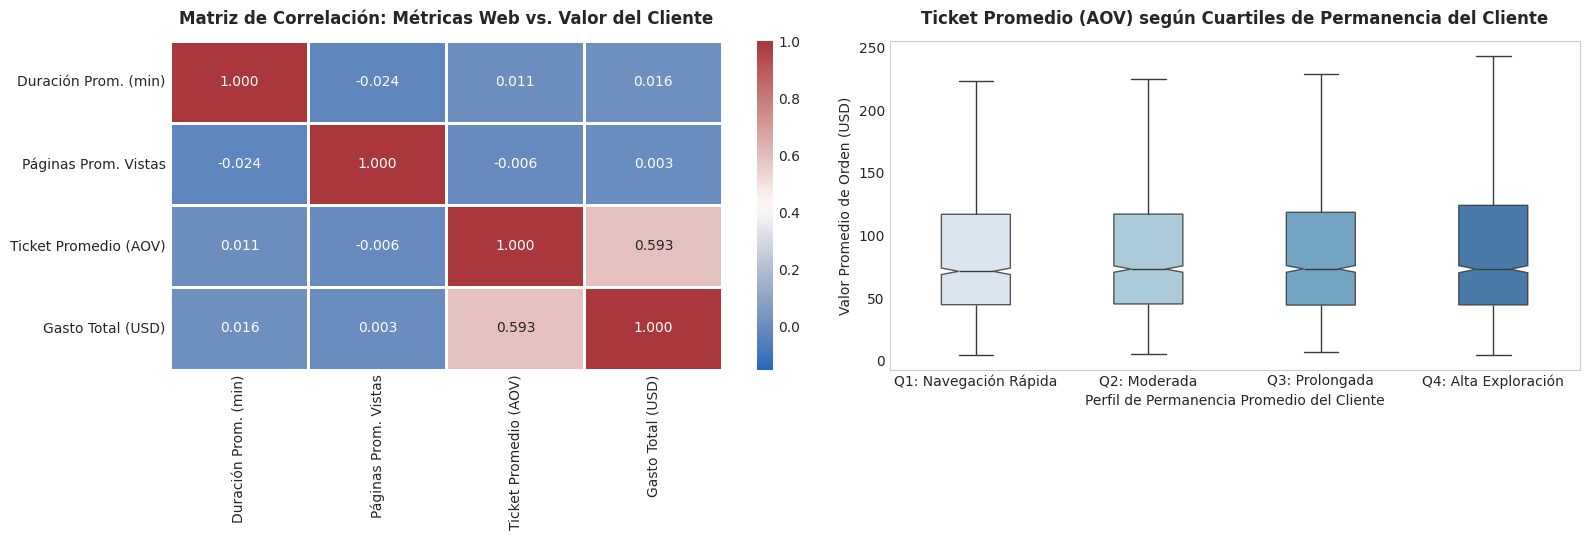

In [58]:
# Segmentar a los clientes en cuartiles según su tiempo promedio de navegación
customers_web_df["engagement_quartile"] = pd.qcut(
    customers_web_df["avg_session_min"],
    q=4,
    labels=[
        "Q1: Navegación Rápida",
        "Q2: Moderada",
        "Q3: Prolongada",
        "Q4: Alta Exploración",
    ],
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# --- GRÁFICO 1: Mapa de Calor de Correlaciones ---
cols_interest = [
    "avg_session_min",
    "avg_pages_viewed",
    "avg_order_value_usd",
    "total_spend_usd",
]
corr_matrix = customers_web_df[cols_interest].corr()

# Renombrar etiquetas para presentación ejecutiva
labels_map = [
    "Duración Prom. (min)",
    "Páginas Prom. Vistas",
    "Ticket Promedio (AOV)",
    "Gasto Total (USD)",
]

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="vlag",
    vmin=-0.15,
    vmax=1.0,
    cbar=True,
    ax=axes[0],
    linewidths=0.8,
    xticklabels=labels_map,
    yticklabels=labels_map,
)

axes[0].set_title(
    "Matriz de Correlación: Métricas Web vs. Valor del Cliente",
    fontsize=12,
    fontweight="bold",
    pad=12,
)

# --- GRÁFICO 2: AOV por Cuartiles de Permanencia Promedio ---
sns.boxplot(
    data=customers_web_df,
    x="engagement_quartile",
    y="avg_order_value_usd",
    palette="Blues",
    ax=axes[1],
    width=0.4,
    boxprops=dict(alpha=0.85),
    hue="engagement_quartile",
    notch=True,
    showfliers=False,
)

axes[1].set_title(
    "Ticket Promedio (AOV) según Cuartiles de Permanencia del Cliente",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[1].set_xlabel("Perfil de Permanencia Promedio del Cliente", fontsize=10)
axes[1].set_ylabel("Valor Promedio de Orden (USD)", fontsize=10)

plt.tight_layout()
plt.show()

**H2: Hipótesis Rechazada**
Los datos empíricos refutan formalmente la hipótesis. La actividad y permanencia en la plataforma web (medida a través de la duración de la sesión y la cantidad de páginas exploradas previa a la compra) no influye en absoluto sobre el valor transaccional del pedido (***total_amount_usd***) ni sobre el Ticket Promedio (***avg_order_value_usd***) o Gasto Total Acumulado del cliente.



1.   Comportamiento Transaccional a Nivel de Pedido (*orders_df*)

    *   La línea de tendencia roja es completamente horizontal sobre un valor medio de ~$150 USD. Transacciones de alto valor ($1,000–$2,500 USD) ocurren de manera indistinta tanto en sesiones ultracortas (<10 minutos) como en sesiones extendidas.
    *   La exploración previa de 1 a 24 páginas no muestra ningún patrón ascendente en la facturación de la orden.

2.   Comportamiento Agregado a Nivel de Cliente (*customers_web_df*)

    * La duración promedio de sesión por cliente presenta una correlación prácticamente inexistente con el Ticket Promedio ($r = 0.011$) y con el Gasto Total ($r = 0.016$).
    * El promedio de páginas vistas muestra el mismo comportamiento nulo frente al Ticket Promedio ($r = -0.006$) y Gasto Total ($r = 0.003$).
    * La distribución del AOV es idéntica entre los cuatro cuartiles de engagement: desde los compradores de Navegación Rápida (Q1) hasta los de Alta Exploración (Q4), la mediana del ticket promedio se mantiene constante en ~$75 USD (con rangos intercuartílicos entre ~$45 y ~$120 USD).


Sesiones más largas o con mayor navegación no equivalen a carros de compra más voluminosos.

### H3: Geo-Segmentación vía API Externa y Tamaño de Mercado vs. Churn:

Aprovechamos la información enriquecida mediante la API REST Countries (region, subregion y market_size) para identificar patrones geográficos en el comportamiento de la base.

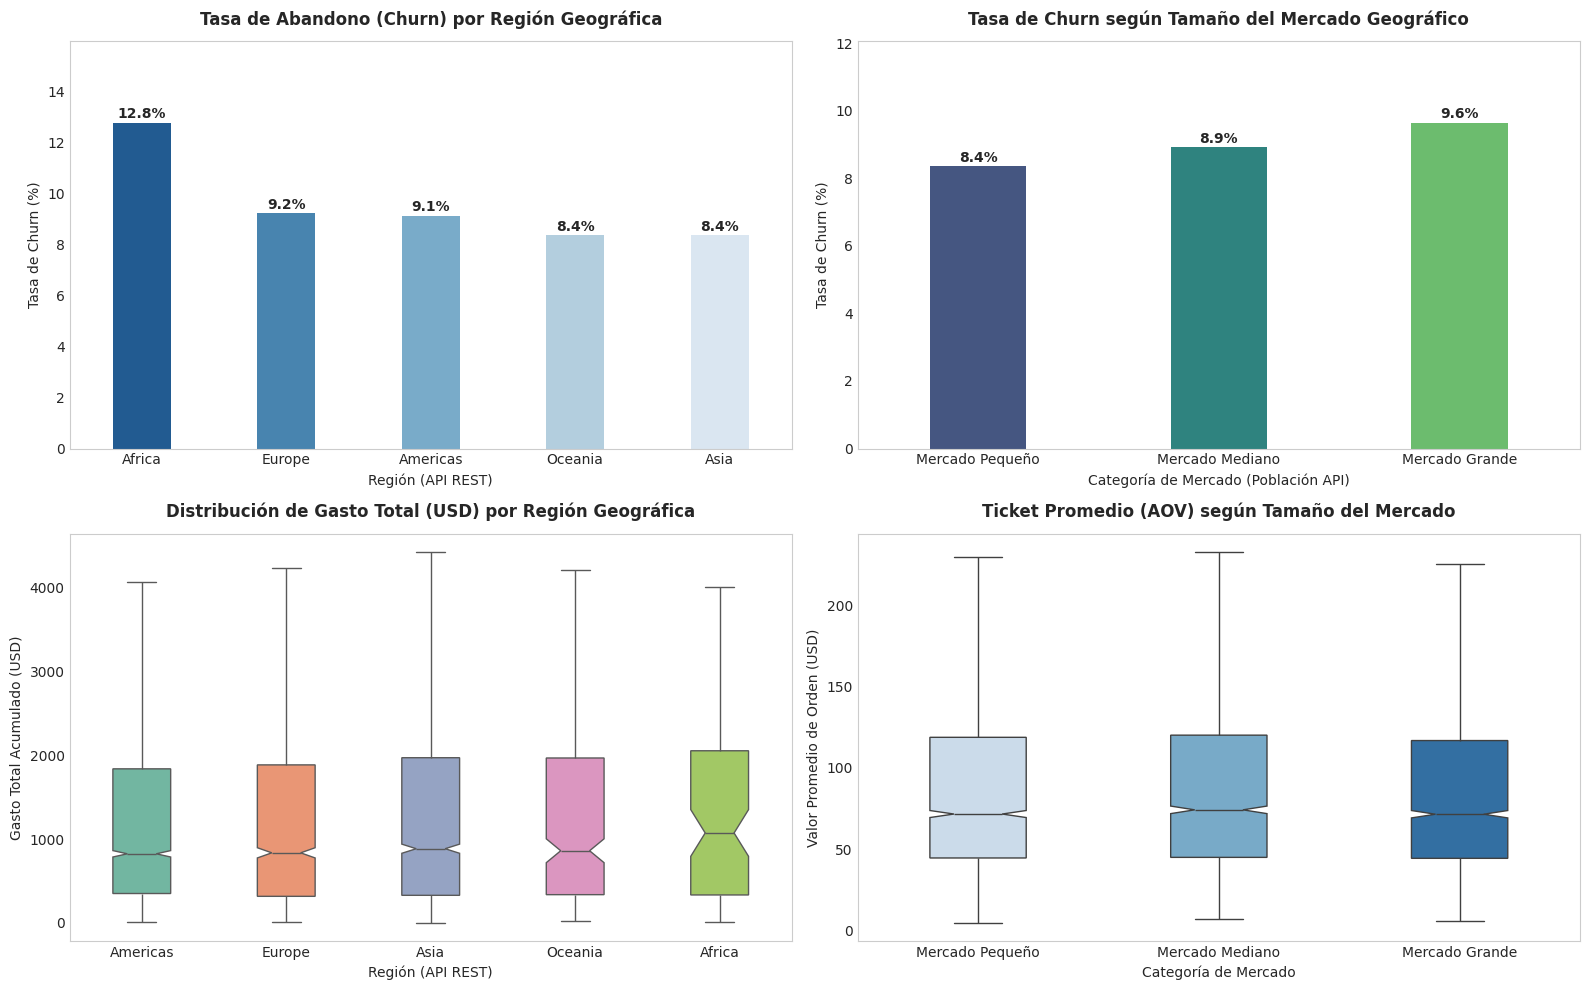

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# 1. Tasa de Churn por Región Geográfica

region_churn = (
    customers_df.groupby("region")["churned"]
    .agg(tasa_churn="mean", total_clientes="count")
    .reset_index()
)
region_churn["tasa_pct"] = region_churn["tasa_churn"] * 100
region_churn = region_churn.sort_values(by="tasa_pct", ascending=False)

bars1 = sns.barplot(
    data=region_churn,
    x="region",
    y="tasa_pct",
    palette="Blues_r",
    ax=axes[0, 0],
    hue="region",
    width=0.4,
)
axes[0, 0].set_title(
    "Tasa de Abandono (Churn) por Región Geográfica",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[0, 0].set_ylabel("Tasa de Churn (%)", fontsize=10)
axes[0, 0].set_xlabel("Región (API REST)", fontsize=10)
axes[0, 0].set_ylim(
    0,
    max(region_churn["tasa_pct"]) * 1.25 if len(region_churn) else 100,
)

for p in bars1.patches:
    axes[0, 0].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 6),
        textcoords="offset points",
        fontweight="bold",
    )


# 2. Tasa de Churn por Tamaño de Mercado
market_churn = (
    customers_df.groupby("market_size", observed=False)["churned"]
    .mean()
    .reset_index()
)
market_churn["tasa_pct"] = market_churn["churned"] * 100

bars2 = sns.barplot(
    data=market_churn,
    x="market_size",
    y="tasa_pct",
    palette="viridis",
    ax=axes[0, 1],
    width=0.4,
    hue="market_size",
)
axes[0, 1].set_title(
    "Tasa de Churn según Tamaño del Mercado Geográfico",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[0, 1].set_ylabel("Tasa de Churn (%)", fontsize=10)
axes[0, 1].set_xlabel("Categoría de Mercado (Población API)", fontsize=10)
axes[0, 1].set_ylim(
    0,
    max(market_churn["tasa_pct"]) * 1.25 if len(market_churn) else 100,
)

for p in bars2.patches:
    axes[0, 1].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 6),
        textcoords="offset points",
        fontweight="bold",
    )


# 3. Gasto Promedio Total (USD) por Región


sns.boxplot(
    data=customers_df,
    x="region",
    y="total_spend_usd",
    palette="Set2",
    ax=axes[1, 0],
    width=0.4,
    hue="region",
    notch=True,
    showfliers=False,
)
axes[1, 0].set_title(
    "Distribución de Gasto Total (USD) por Región Geográfica",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[1, 0].set_ylabel("Gasto Total Acumulado (USD)", fontsize=10)
axes[1, 0].set_xlabel("Región (API REST)", fontsize=10)


# 4. Ticket Promedio (AOV) por Tamaño de Mercado

sns.boxplot(
    data=customers_df,
    x="market_size",
    y="avg_order_value_usd",
    palette="Blues",
    ax=axes[1, 1],
    width=0.4,
    hue="market_size",
    notch=True,
    showfliers=False,
)
axes[1, 1].set_title(
    "Ticket Promedio (AOV) según Tamaño del Mercado",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[1, 1].set_ylabel("Valor Promedio de Orden (USD)", fontsize=10)
axes[1, 1].set_xlabel("Categoría de Mercado", fontsize=10)

plt.tight_layout()
plt.show()

**Analisis Multivariado:**

Analiza qué regiones geográficas y tamaños de mercado concentran el mayor volumen de ventas y dónde hay mayor riesgo de churn.

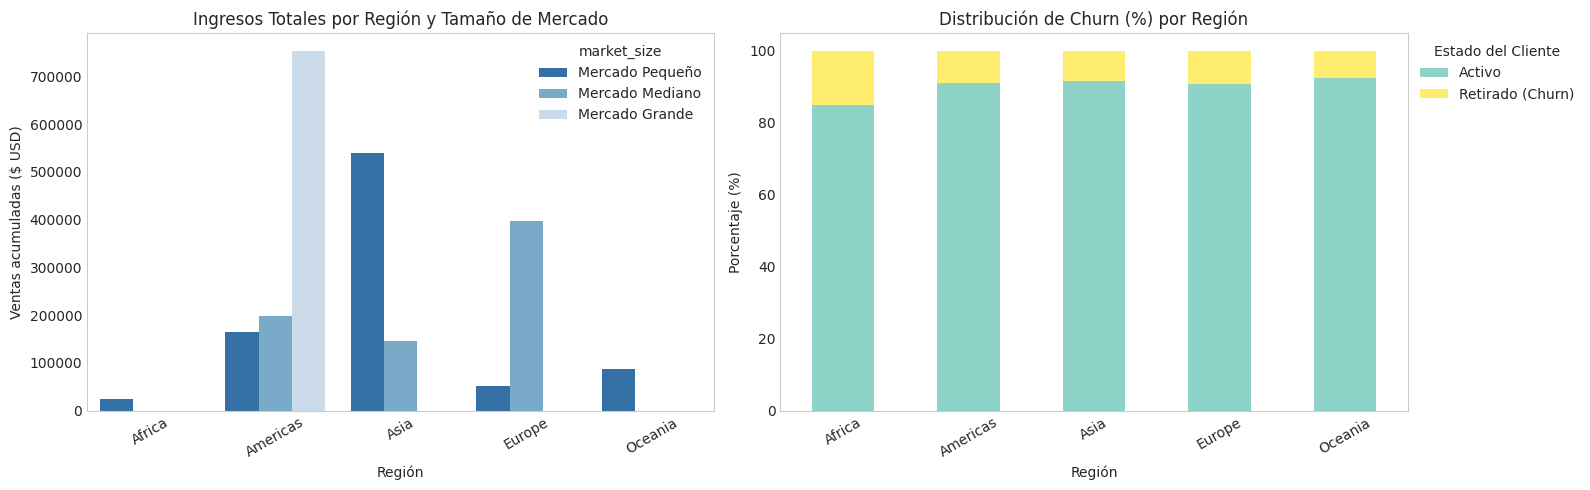

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ventas Totales por Región y Tamaño de Mercado
region_sales = full_orders_df.groupby(['region', 'market_size'],  observed=False )['avg_order_value_usd'].sum().reset_index()

sns.barplot(
    data=region_sales,
    x='region',
    y='avg_order_value_usd',
    hue='market_size',
    palette='Blues_r',
    ax=axes[0],
)
axes[0].set_title('Ingresos Totales por Región y Tamaño de Mercado', fontsize=12)
axes[0].set_xlabel('Región')
axes[0].set_ylabel('Ventas acumuladas ($ USD)')
axes[0].tick_params(axis='x', rotation=30)

# Tasa de Churn por Región
region_churn = pd.crosstab(
    full_orders_df['region'],
    full_orders_df['churn_label'],
    normalize='index'
) * 100

region_churn.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3' )
axes[1].set_title('Distribución de Churn (%) por Región', fontsize=12)
axes[1].set_xlabel('Región')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Estado del Cliente', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

**H3: Hipótesis Parcialmente Aceptada (con Anomalía Regional)**
Los datos empíricos no muestran diferencias sustanciales en la capacidad de gasto ni en el ticket promedio entre regiones geográficas o tamaños de mercado. Sin embargo, la hipótesis se valida parcialmente en la dimensión de retención, revelando un problema crítico focalizado en la región de África, que registra una tasa de abandono sensiblemente superior al promedio global.


1.   Retención y Abandono Geográfico

  *   Tasa de Churn por Región Geográfica:
      *   África: Presenta la tasa de churn más alta de la plataforma con 12.8%, superando por más de 3.5 puntos porcentuales a cualquier otra región.
      *   Europa y Américas: Muestran un comportamiento alineado al promedio global, con 9.2% y 9.1% de churn respectivamente.
      *   Oceanía y Asia: Registran los mejores niveles de retención con un 8.4% de abandono
  *   Tasa de Churn por Tamaño del Mercado (Población API):
      *   Se observa una ligera tendencia ascendente en el churn a medida que aumenta el tamaño del mercado: Mercado Pequeño (8.4%) $\rightarrow$ Mercado Mediano (8.9%) $\rightarrow$ Mercado Grande (9.6%)


2.   Comportamiento Monetario y de Compra

      *   La distribución del gasto histórico es homogénea entre continentes. La mediana de gasto se sitúa entre $800 y $1,000 USD en todas las regiones,
      *   Los clientes de África muestran una mediana de gasto acumulado ligeramente superior (~$1,050 USD), lo que agrava el impacto financiero de su alta tasa de abandono.   
      *   La mediana del AOV es idéntica entre los tres tamaños de mercado (~$72 - $75 USD), con rangos intercuartílicos casi idénticos ($45 – $120 USD).

3.   Hallazgos del Análisis Multivariado:

  *   Americas lidera ampliamente las ventas acumuladas, destacando en el segmento de Mercado Grande con más de $750,000 USD, seguido por Mercado Mediano ($200,000 USD) y Mercado Pequeño ($165,000 USD).  

  *   Asia concentra sus ventas en Mercado Pequeño ($540,000 USD), mientras que Europe destaca en Mercado Mediano ($400,000 USD).   
  *   África registra el nivel más bajo de ingresos acumulados (~$25,000 USD)



**Insights**

La paridad en el AOV a través de los distintos tamaños de mercado confirma que la propuesta de precios y empaquetado de productos funciona de forma consistente sin importar la densidad poblacional del país destino.

Los clientes africanos gastan al mismo nivel o incluso ligeramente más que el resto del mundo, su tasa de churn del 12.8% sugiere fricciones logísticas, de tiempos de entrega o en las pasarelas de pago locales, y no un desinterés comercial por el catálogo.

Se sugiere priorizar recursos de adquisición en Americas (Mercados Grandes) y Asia (Mercados Pequeños). Revisar la estrategia comercial y logística en África para mitigar la tasa de abandono de usuarios en esa región.





### H4 (Evolución Histórica de la Facturación Mensual, Patrones de Estacionalidad y Tendencia de Crecimiento).

Evalúa la serie temporal completa (2020-2026), calculando la media móvil de 6 meses, la concentración de ventas por mes del año, el comportamiento interanual y un mapa de calor (heatmap) para detectar picos estacionales

**`1. Agreagciones y preparacion de Series temporales`**

In [62]:
#1. Agregación Mensual (Serie Temporal)
monthly_sales = (
    orders_df.resample("ME", on="order_date")["total_amount_usd"]
    .sum()
    .reset_index()
)


monthly_sales["rolling_avg_6m"] = (
    monthly_sales["total_amount_usd"].rolling(window=6).mean()
)

monthly_sales["year"] = monthly_sales["order_date"].dt.year
monthly_sales["month"] = monthly_sales["order_date"].dt.month

print("Monto Total Facrutado Mensual:", monthly_sales)

# 2. Agregación por Mes del Año (Estacionalidad Promedio)
month_names = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]
seasonality = (
    orders_df.groupby("month")["total_amount_usd"].sum().reset_index()
)
seasonality["month_name"] = [
    month_names[m - 1] for m in seasonality["month"]
]

print("Promedio Mensual de Ventas:", seasonality)


# 3. Agregación Anual
annual_sales = (
    orders_df.groupby("year")["total_amount_usd"].sum().reset_index()
)

print("Monto Total Facturado Anual:", annual_sales)

# 4. Matriz Año vs. Mes para Heatmap
pivot_sales = orders_df.pivot_table(
    index="year",
    columns="month",
    values="total_amount_usd",
    aggfunc="sum",
    fill_value=0,
)
pivot_sales.columns = month_names

print("Matriz de Ventas Anual vs. Mensual:", pivot_sales)


Monto Total Facrutado Mensual:    order_date  total_amount_usd  rolling_avg_6m  year  month
0  2020-01-31          41113.87             NaN  2020      1
1  2020-02-29          39807.11             NaN  2020      2
2  2020-03-31          42025.89             NaN  2020      3
3  2020-04-30          42924.92             NaN  2020      4
4  2020-05-31          47225.52             NaN  2020      5
..        ...               ...             ...   ...    ...
70 2025-11-30          36966.74    44461.890000  2025     11
71 2025-12-31          47489.61    44067.936667  2025     12
72 2026-01-31          51490.91    44880.693333  2026      1
73 2026-02-28          46117.73    45158.985000  2026      2
74 2026-03-31          40326.58    45021.828333  2026      3

[75 rows x 5 columns]
Promedio Mensual de Ventas:     month  total_amount_usd month_name
0       1         299356.14        Ene
1       2         269104.85        Feb
2       3         300275.43        Mar
3       4         242767.43   

**`2. Graficos:`**

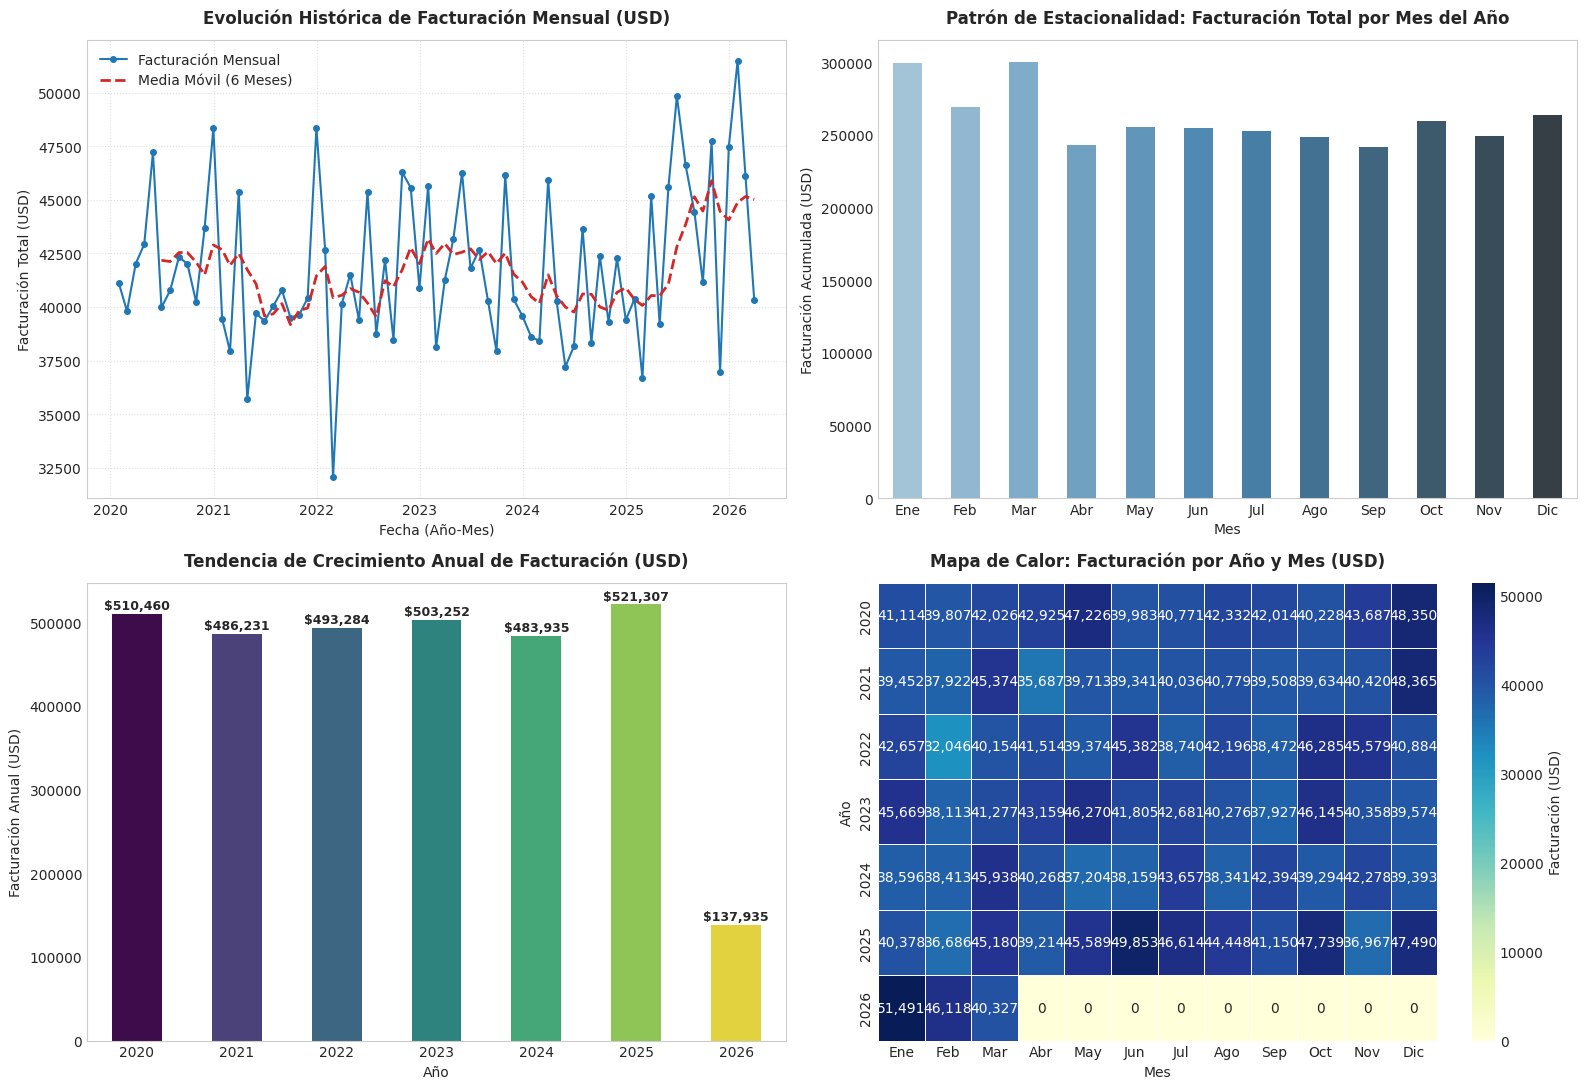

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# --- GRÁFICO 1: Evolución Temporal Mensual + Media Móvil ---
axes[0, 0].plot(
    monthly_sales["order_date"],
    monthly_sales["total_amount_usd"],
    marker="o",
    linewidth=1.5,
    markersize=4,
    color="#1f77b4",
    label="Facturación Mensual",
)
axes[0, 0].plot(
    monthly_sales["order_date"],
    monthly_sales["rolling_avg_6m"],
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label="Media Móvil (6 Meses)",
)
axes[0, 0].set_title(
    "Evolución Histórica de Facturación Mensual (USD)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[0, 0].set_ylabel("Facturación Total (USD)", fontsize=10)
axes[0, 0].set_xlabel("Fecha (Año-Mes)", fontsize=10)
axes[0, 0].legend(loc="upper left")
axes[0, 0].grid(True, linestyle=":", alpha=0.6)

# --- GRÁFICO 2: Estacionalidad Acumulada por Mes ---
bars2 = sns.barplot(
    data=seasonality,
    x="month_name",
    y="total_amount_usd",
    palette="Blues_d",
    ax=axes[0, 1],
    hue="month_name",
    width=0.5,
)
axes[0, 1].set_title(
    "Patrón de Estacionalidad: Facturación Total por Mes del Año",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[0, 1].set_ylabel("Facturación Acumulada (USD)", fontsize=10)
axes[0, 1].set_xlabel("Mes", fontsize=10)

# --- GRÁFICO 3: Crecimiento Anual ---
bars3 = sns.barplot(
    data=annual_sales,
    x="year",
    y="total_amount_usd",
    palette="viridis",
    ax=axes[1, 0],
    width=0.5,
    hue="year",
    legend=False,
)
axes[1, 0].set_title(
    "Tendencia de Crecimiento Anual de Facturación (USD)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[1, 0].set_ylabel("Facturación Anual (USD)", fontsize=10)
axes[1, 0].set_xlabel("Año", fontsize=10)

for p in bars3.patches:
    axes[1, 0].annotate(
        f"${p.get_height():,.0f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 6),
        textcoords="offset points",
        fontweight="bold",
        fontsize=9,
    )

# --- GRÁFICO 4: Heatmap Año vs. Mes ---
sns.heatmap(
    pivot_sales,
    annot=True,
    fmt=",.0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[1, 1],
    cbar_kws={"label": "Facturación (USD)"},
)
axes[1, 1].set_title(
    "Mapa de Calor: Facturación por Año y Mes (USD)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[1, 1].set_xlabel("Mes", fontsize=10)
axes[1, 1].set_ylabel("Año", fontsize=10)

plt.tight_layout()
plt.show()

**Analisis Bivariado:**

Evalua la tendencia de ventas y detectar estacionalidades entre 2020 y 2026.

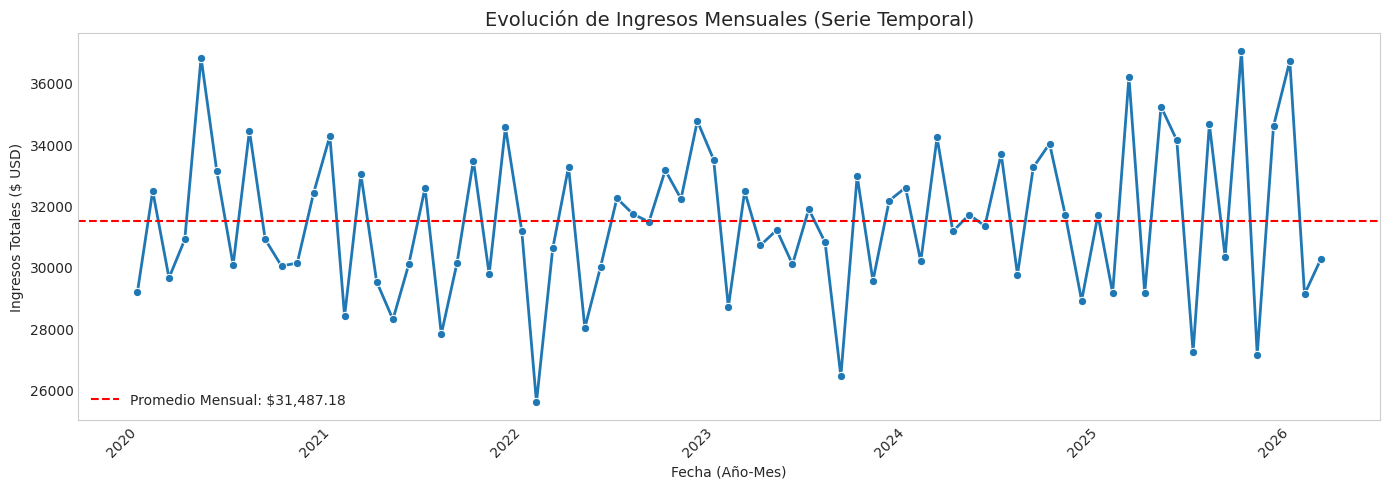

In [64]:
# Asegurar formato datetime y agrupación mensual
full_orders_df['order_date'] = pd.to_datetime(full_orders_df['order_date'])
monthly_revenue = full_orders_df.set_index('order_date').resample('ME')['avg_order_value_usd'].sum().reset_index()

plt.figure(figsize=(14, 5))

# Serie temporal
sns.lineplot(
    data=monthly_revenue,
    x='order_date',
    y='avg_order_value_usd',
    marker='o',
    color='#1f77b4',
    linewidth=2
)

# Promedio global de ingresos mensuales
plt.axhline(
    monthly_revenue['avg_order_value_usd'].mean(),
    color='red',
    linestyle='--',
    label=f"Promedio Mensual: ${monthly_revenue['avg_order_value_usd'].mean():,.2f}"
)

plt.title('Evolución de Ingresos Mensuales (Serie Temporal)', fontsize=14)
plt.xlabel('Fecha (Año-Mes)')
plt.ylabel('Ingresos Totales ($ USD)')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**H4: Hipótesis Parcialmente Validada (Negocio Maduro y Estabilizado)**
El análisis histórico confirma que la facturación del negocio se encuentra en una etapa de alta madurez y estabilidad estructural. Si bien existe una estacionalidad moderada con picos en el primer trimestre (Q1) y en el cierre de año (Q4), la facturación anual no muestra un crecimiento exponencial, sino que oscila en una banda consolidada de entre **$483K y $521K** USD anuales.

No obstante, la serie reciente (2025 - inicio de 2026) refleja un impulso alcista relevante, alcanzando récords históricos de facturación mensual.



1.   Evolución Temporal Mensual y Media Móvil (*orders_df*)

    *   La facturación mensual oscila históricamente en un rango de entre **$32,000 USD** (mínimo histórico en febrero de 2022) y **$51,491 USD **(máximo histórico en enero de 2026)
    *   La media móvil de 6 meses se mantuvo plana entre los **$40,000** y **$43,000 USD** durante el periodo 2020–2024. Sin embargo, a partir del segundo semestre de 2025 muestra una tendencia ascendente hacia los **$45,000 USD**,

2.  Patrón de Estacionalidad Acumulada:

    *   Q1 Comercial (Enero y Marzo): Representan los meses de mayor concentración de ventas acumuladas, bordeando los $300,000 USD cada uno.
    *   Récord Histórico 2025: Se alcanzó la cifra récord de $521,307 USD, representando un crecimiento del +7.7% respecto a 2024.
    *   Avance de 2026: El primer trimestre (enero - marzo) acumula $137,935 USD, superando el ritmo promedio proyectado para el mismo trimestre de años anteriores.

3.   Tendencia de Crecimiento Anual (2020–2026)

    *   2020 a 2024: El volumen de facturación anual fue extremadamente constante: $510,460 USD (2020), $486,231 USD (2021), $493,284 USD (2022), $503,252 USD (2023) y $483,935 USD (2024).  
    *   Récord Histórico 2025: Se alcanzó la cifra récord de $521,307 USD, representando un crecimiento del +7.7% respecto a 2024.
    *   Avance de 2026: El primer trimestre (enero - marzo) acumula $137,935 USD,     

4.   Mapa de Calor (Año vs. Mes)

    *   Destaca el desempeño de junio de 2025 ($49,853 USD) y enero de 2026 ($51,491 USD) como los meses con mayor volumen de facturación del dataset completo.

5.   Análisis Multivariado: Serie temporal

    *   La serie temporal (2020-2026) muestra estabilidad alrededor del promedio, observándose picos de mayor amplitud entre 2025 y 2026 que alcanzan valores cercanos a $37,000 USD.

**Insigts**

*   El patrón estacional recurrente en Q1 (Enero - Marzo), el abastecimiento de stock y la capacidad operativa de despacho deben prepararse desde noviembre y diciembre para evitar cuellos de botella en la entrada de año.
*    El modelo de negocio se encuentra en una meseta de madurez ($480K–$520K USD/año).
*    El incremento observado a partir de finales de 2025 sugiere que las estrategias comerciales recientes están funcionando
*    Se sugiere diseñar campañas promocionales o incentivos en los meses de menor facturación histórica para estabilizar el flujo de caja y mitigar la volatilidad entre periodos.